# Notebook 01 — Inspección Inicial
## Dataset: streaming_users_dirty.json
**Objetivo:** Explorar la estructura y calidad inicial del dataset sin aplicar ninguna transformación. Solo observar y documentar.

In [4]:
import os

# Crear la estructura obligatoria de GitHub en Colab
raiz = '/content/PI_Mineria_Datos_1'
os.makedirs(f'{raiz}/data/raw', exist_ok=True)
os.makedirs(f'{raiz}/data/processed', exist_ok=True)
os.makedirs(f'{raiz}/notebooks', exist_ok=True)
os.makedirs(f'{raiz}/logs', exist_ok=True)

# Cambiar el directorio activo a la carpeta de notebooks
%cd /content/PI_Mineria_Datos_1/notebooks

/content/PI_Mineria_Datos_1/notebooks


In [5]:
# Importación de librerías
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Carga del dataset
El archivo contiene valores NaN literales que no son JSON válido. Se reemplazan por null antes de parsear.

In [6]:
# IMPORTANTE: primero subí el archivo a Colab usando el ícono de carpeta
# en el panel izquierdo → "Subir archivo"

file_path = '../data/raw/streaming_users_dirty.json'

with open(file_path, 'r', encoding='utf-8') as f:
    contenido = f.read()
    contenido_corregido = contenido.replace('NaN', 'null')
    data = json.loads(contenido_corregido)

df = pd.DataFrame(data)
print(f"Dataset cargado. Forma: {df.shape}")

Dataset cargado. Forma: (8160, 8)


## 2. Dimensiones y tipos de datos

In [7]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("\nTipos de datos:")
print(df.dtypes)

Filas: 8160
Columnas: 8

Tipos de datos:
user_id                       int64
age                           int64
subscription_plan            object
monthly_watch_time_mins     float64
country                      object
favorite_genre               object
last_login_date              object
customer_support_tickets      int64
dtype: object


## 3. Primeras y últimas filas

In [8]:
print("Primeras 5 filas:")
display(df.head())
print("\nÚltimas 5 filas:")
display(df.tail())

Primeras 5 filas:


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1



Últimas 5 filas:


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
8155,10923,23,Premium,1161.4,Colombia,Romance,2023-05-15,0
8156,16525,27,Básico,436.2,Uruguay,Documental,2018-09-06,4
8157,11222,13,Estándar,1321.8,México,Documental,2019-02-08,0
8158,15613,38,Estándar,835.7,Brasil,Drama,2022-02-05,0
8159,16912,25,Estándar,1468.7,Argentina,Romance,2022-08-12,3


## 4. Valores nulos

,Nulos,Porcentaje (%)
last_login_date,320,3.92
favorite_genre,240,2.94
monthly_watch_time_mins,193,2.37
user_id,0,0.00
subscription_plan,0,0.00
age,0,0.00
country,0,0.00
customer_support_tickets,0,0.00


/tmp/ipykernel_2908/472668326.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cols_con_nulos.index, y='Nulos', data=cols_con_nulos, palette='Reds_r')


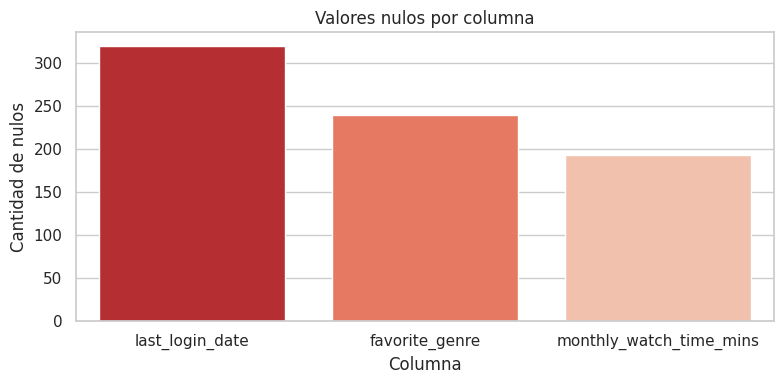

In [9]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Nulos', ascending=False)

display(resumen_nulos)

# Gráfico de nulos
plt.figure(figsize=(8, 4))
cols_con_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
sns.barplot(x=cols_con_nulos.index, y='Nulos', data=cols_con_nulos, palette='Reds_r')
plt.title('Valores nulos por columna')
plt.ylabel('Cantidad de nulos')
plt.xlabel('Columna')
plt.tight_layout()
plt.show()

## 5. Duplicados

In [10]:
dup_totales = df.duplicated().sum()
dup_userid = df.duplicated(subset=['user_id']).sum()

print(f"Filas exactamente duplicadas: {dup_totales}")
print(f"user_id duplicados: {dup_userid}")
print(f"user_id únicos: {df['user_id'].nunique()}")

Filas exactamente duplicadas: 126
user_id duplicados: 160
user_id únicos: 8000


## 6. Estadísticas descriptivas

In [11]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df.describe())

,user_id,age,monthly_watch_time_mins,customer_support_tickets
count,8160.00,8160.00,7967.00,8160.00
mean,13995.43,34.10,1107.35,1.80
std,2310.81,14.51,5310.44,11.33
min,10000.00,-5.00,-120.00,-1.00
25%,11987.75,25.00,489.20,0.00
50%,13998.50,33.00,757.40,1.00
75%,15997.25,42.00,1045.70,1.00
max,17999.00,150.00,99999.00,150.00


## 7. Valores únicos en columnas categóricas

In [12]:
for col in ['subscription_plan', 'country', 'favorite_genre']:
    print(f"\n--- {col} ({df[col].nunique()} valores únicos) ---")
    print(df[col].value_counts(dropna=False))


--- subscription_plan (15 valores únicos) ---
subscription_plan
Básico       3450
Estándar     2711
Premium      1519
basico         60
BASICO         52
Basic          52
básico         50
Std            48
Estándar       46
estandar       36
STANDARD       34
Premium        31
PREMIUM        26
Premiun        23
premium        22
Name: count, dtype: int64

--- country (26 valores únicos) ---
country
Brasil        1132
Chile         1132
México        1129
Uruguay       1124
Perú          1120
Colombia      1116
Argentina     1087
colombia        27
méxico          25
uruguay         24
Brazil          21
COL             19
CHL             18
URY             17
argentina       16
MEX             16
Chile           16
PER             16
Peru            15
BRA             15
chile           15
Mexico          15
brasil          13
perú            12
ARG             10
Argentina       10
Name: count, dtype: int64

--- favorite_genre (28 valores únicos) ---
favorite_genre
Comedia        

## 8. Observaciones iniciales

A partir de la inspección se detectaron los siguientes problemas a resolver en el notebook 02:

- **Nulos:** monthly_watch_time_mins (193), favorite_genre (240), last_login_date (320)
- **Duplicados:** 126 filas idénticas, 160 user_id repetidos
- **Inconsistencias de texto:** subscription_plan, country y favorite_genre tienen múltiples variantes del mismo valor
- **Outliers en age:** valores negativos, cero, y mayores a 100
- **Outliers en monthly_watch_time_mins:** valor 99999 (código de error), valores negativos
- **Outliers en customer_support_tickets:** valor -1 (imposible), valores 99 y 150
- **Fechas futuras:** last_login_date contiene fechas hasta 2029